In [18]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("../runs/detect/digit_detector4/weights/best.pt")

In [19]:
image_path = "3.jpg"
result = model(image_path)[0]

img_original = result.orig_img.copy()

CONF_ORIG = 0.4
CONF_CROP = 0.5


image 1/1 /Users/ofekhazum-Study/Desktop/study/DataScience/ClocksDL/digital_clock_notebooks/3.jpg: 224x512 1 1, 1 2, 2 3s, 1 5, 1 9, 46.8ms
Speed: 1.2ms preprocess, 46.8ms inference, 0.7ms postprocess per image at shape (1, 3, 224, 512)


In [20]:
original_detections = []

for box in result.boxes:
    conf = float(box.conf[0])

    if conf < CONF_ORIG:
        continue

    cls_id = int(box.cls[0])
    label = model.names[cls_id]

    x1,y1,x2,y2 = box.xyxy[0].tolist()
    xc = (x1+x2)/2
    yc = (y1+y2)/2

    original_detections.append((label, conf, [x1,y1,x2,y2], xc, yc, "orig"))

In [21]:
original_detections

[('2',
  0.9460822939872742,
  [554.8027954101562, 130.3997344970703, 729.4611206054688, 373.57958984375],
  642.1319580078125,
  251.98966217041016,
  'orig'),
 ('9',
  0.9291477799415588,
  [1179.624267578125,
   133.45481872558594,
   1342.3924560546875,
   380.1810607910156],
  1261.0083618164062,
  256.8179397583008,
  'orig'),
 ('3',
  0.9175080060958862,
  [298.65643310546875,
   126.94717407226562,
   459.06964111328125,
   375.159912109375],
  378.863037109375,
  251.0535430908203,
  'orig'),
 ('5',
  0.9143341183662415,
  [735.9314575195312, 132.12071228027344, 886.727783203125, 375.3507385253906],
  811.3296203613281,
  253.73572540283203,
  'orig'),
 ('3',
  0.8882739543914795,
  [1016.9331665039062, 131.75010681152344, 1172.2392578125, 380.0835876464844],
  1094.5862121582031,
  255.9168472290039,
  'orig'),
 ('1',
  0.858233630657196,
  [129.17269897460938,
   135.7590789794922,
   290.4702453613281,
   363.4267272949219],
  209.82147216796875,
  249.59290313720703,
  'or

(-0.5, 1472.5, 601.5, -0.5)

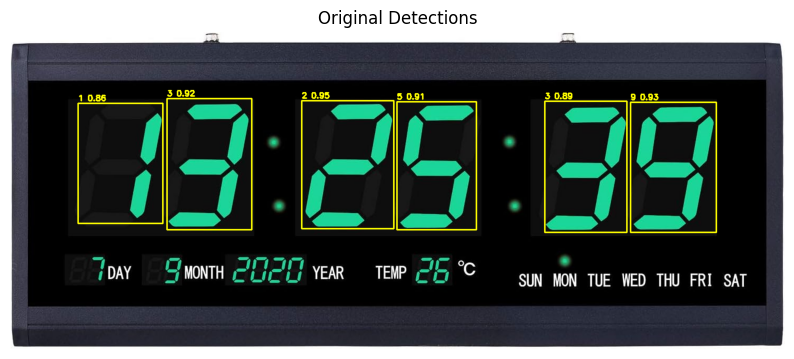

In [22]:
img = img_original.copy()

for label, conf, box, x, y, src in original_detections:
    x1,y1,x2,y2 = map(int, box)

    cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,255),2)
    cv2.putText(img,f"{label} {conf:.2f}",(x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,255),2)

plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Detections")
plt.axis("off")

In [23]:
def sliding_collect(model, image, window_size=416, stride=200):

    h, w = image.shape[:2]
    detections = []

    for y in range(0, h, stride):
        for x in range(0, w, stride):

            crop = image[y:y+window_size, x:x+window_size]

            if crop.shape[0] < 50 or crop.shape[1] < 50:
                continue

            results = model(crop)[0]

            for box in results.boxes:
                conf = float(box.conf[0])
                if conf < CONF_CROP:
                    continue

                cls_id = int(box.cls[0])
                label = model.names[cls_id]

                x1,y1,x2,y2 = box.xyxy[0].tolist()

                x1 += x
                x2 += x
                y1 += y
                y2 += y

                xc = (x1 + x2)/2
                yc = (y1 + y2)/2

                detections.append((label, conf, [x1,y1,x2,y2], xc, yc, "crop"))

    return detections


sliding_detections = sliding_collect(model, img_original)
print("Sliding detections:", len(sliding_detections))


0: 512x512 1 1, 1 3, 61.6ms
Speed: 1.8ms preprocess, 61.6ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 512)

0: 512x512 1 1, 1 2, 1 3, 62.3ms
Speed: 1.6ms preprocess, 62.3ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 512)

0: 512x512 1 2, 1 7, 2 9s, 55.9ms
Speed: 1.4ms preprocess, 55.9ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)

0: 512x512 1 2, 1 5, 67.9ms
Speed: 1.3ms preprocess, 67.9ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)

0: 512x512 1 2, 1 3, 1 5, 1 6, 61.4ms
Speed: 2.0ms preprocess, 61.4ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 512)

0: 512x512 1 3, 1 9, 58.0ms
Speed: 1.7ms preprocess, 58.0ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 512)

0: 512x352 1 9, 41.9ms
Speed: 2.6ms preprocess, 41.9ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 352)

0: 512x96 (no detections), 22.6ms
Speed: 2.3ms preprocess, 22.6ms inference, 0.3ms postprocess per im

(-0.5, 1472.5, 601.5, -0.5)

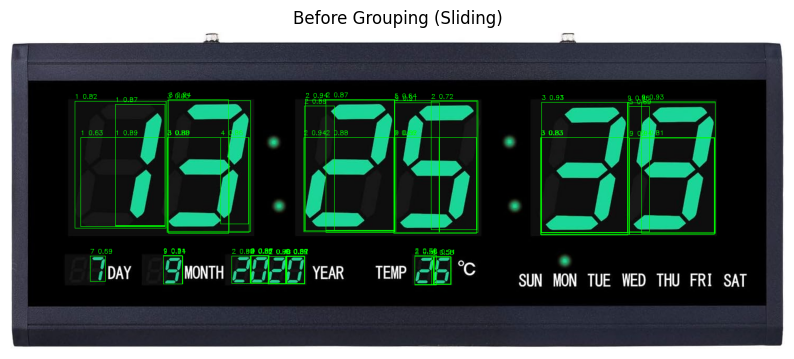

In [24]:
img = img_original.copy()

for label, conf, box, x, y, src in sliding_detections:
    x1,y1,x2,y2 = map(int, box)

    color = (0,255,0) if label.isdigit() else (255,0,0)

    cv2.rectangle(img,(x1,y1),(x2,y2),color,1)
    cv2.putText(img,f"{label} {conf:.2f}",(x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,0.4,color,1)

plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Before Grouping (Sliding)")
plt.axis("off")

In [25]:
def compute_iou(box1, box2):
    x1,y1,x2,y2 = box1
    x1b,y1b,x2b,y2b = box2

    inter_x1 = max(x1,x1b)
    inter_y1 = max(y1,y1b)
    inter_x2 = min(x2,x2b)
    inter_y2 = min(y2,y2b)

    inter = max(0, inter_x2-inter_x1)*max(0, inter_y2-inter_y1)

    a1 = (x2-x1)*(y2-y1)
    a2 = (x2b-x1b)*(y2b-y1b)

    union = a1 + a2 - inter
    return inter/union if union>0 else 0

In [26]:
def group_boxes(items, iou_thresh=0.1):
    groups = []

    for item in items:
        placed = False

        for group in groups:
            for g in group:
                if compute_iou(item[2], g[2]) > iou_thresh:
                    group.append(item)
                    placed = True
                    break
            if placed:
                break

        if not placed:
            groups.append([item])

    return groups


def merge_groups(groups, iou_thresh=0.1):
    merged = True

    while merged:
        merged = False
        new_groups = []

        while groups:
            g1 = groups.pop(0)

            i = 0
            while i < len(groups):
                g2 = groups[i]

                if any(compute_iou(a[2], b[2]) > iou_thresh for a in g1 for b in g2):
                    g1.extend(g2)
                    groups.pop(i)
                    merged = True
                else:
                    i += 1

            new_groups.append(g1)

        groups = new_groups

    return groups

In [27]:
# def select_best(groups):
#     final = []

#     for group in groups:

#         best = None

#         for item in group:
#             label, conf, box, x, y, src = item

#             if best is None:
#                 best = item
#                 continue

#             _, best_conf, best_box, _, _, _ = best

#             area = (box[2]-box[0])*(box[3]-box[1])
#             best_area = (best_box[2]-best_box[0])*(best_box[3]-best_box[1])

#             # 🔥 אם הבוקס קטן יותר → צריך להיות הרבה יותר בטוח
#             if area < best_area:
#                 if conf > best_conf + 0.15:
#                     best = item

#             # 🔥 אם הבוקס גדול יותר → עדיפות טבעית
#             else:
#                 if conf > best_conf:
#                     best = item

#         final.append(best)

#     return final

# def select_best(groups):
#     final = []

#     for group in groups:

#         # 🔥 כל הזיהויים מהמקור
#         orig_items = [g for g in group if g[5] == "orig"]

#         if orig_items:
#             # 👉 קח את הכי טוב מהמקור בלבד
#             best = max(orig_items, key=lambda x: x[1])

#         else:
#             # fallback רגיל
#             best = max(group, key=lambda x: x[1])

#         final.append(best)

#     return final

def box_area(box):
    return (box[2] - box[0]) * (box[3] - box[1])


def select_best(groups):
    final = []

    for group in groups:

        # ===== הפרדה =====
        orig_items = [g for g in group if g[5] == "orig"]
        crop_items = [g for g in group if g[5] == "crop"]

        # =========================
        # 🔵 מקרה 1: יש ORIG
        # =========================
        if orig_items:
            best_orig = max(orig_items, key=lambda x: x[1])

            # האם crop מנצח משמעותית?
            if crop_items:
                best_crop = max(crop_items, key=lambda x: x[1])

                if best_crop[1] > best_orig[1] + 0.5:
                    best = best_crop
                else:
                    best = best_orig
            else:
                best = best_orig

        # =========================
        # 🟢 מקרה 2: אין ORIG
        # =========================
        else:
            # הבוקס הכי גדול
            largest = max(group, key=lambda x: box_area(x[2]))
            largest_area = box_area(largest[2])
            largest_conf = largest[1]

            best = largest

            for item in group:
                area = box_area(item[2])
                conf = item[1]

                # אם קטן יותר אבל הרבה יותר בטוח
                if area < largest_area:
                    if conf > largest_conf + 0.25:
                        best = item

        final.append(best)

    return final

all_detections = original_detections + sliding_detections

groups = group_boxes(all_detections)
groups = merge_groups(groups)

filtered = select_best(groups)

print("Final detections:", len(filtered))

Final detections: 13


(-0.5, 1472.5, 601.5, -0.5)

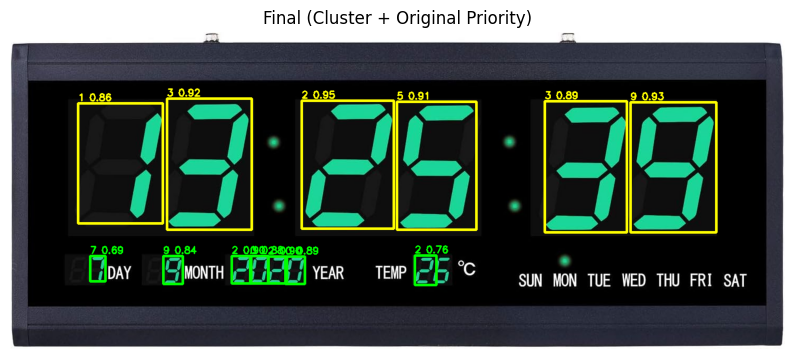

In [28]:
img = img_original.copy()

for label, conf, box, x, y, src in filtered:
    x1,y1,x2,y2 = map(int, box)

    if src == "orig":
        color = (0,255,255)  # צהוב למקור
    else:
        color = (0,255,0)

    cv2.rectangle(img,(x1,y1),(x2,y2),color,3)
    cv2.putText(img,f"{label} {conf:.2f}",(x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,0.6,color,2)

plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Final (Cluster + Original Priority)")
plt.axis("off")

In [29]:
filtered

[('2',
  0.9460822939872742,
  [554.8027954101562, 130.3997344970703, 729.4611206054688, 373.57958984375],
  642.1319580078125,
  251.98966217041016,
  'orig'),
 ('9',
  0.9291477799415588,
  [1179.624267578125,
   133.45481872558594,
   1342.3924560546875,
   380.1810607910156],
  1261.0083618164062,
  256.8179397583008,
  'orig'),
 ('3',
  0.9175080060958862,
  [298.65643310546875,
   126.94717407226562,
   459.06964111328125,
   375.159912109375],
  378.863037109375,
  251.0535430908203,
  'orig'),
 ('5',
  0.9143341183662415,
  [735.9314575195312, 132.12071228027344, 886.727783203125, 375.3507385253906],
  811.3296203613281,
  253.73572540283203,
  'orig'),
 ('3',
  0.8882739543914795,
  [1016.9331665039062, 131.75010681152344, 1172.2392578125, 380.0835876464844],
  1094.5862121582031,
  255.9168472290039,
  'orig'),
 ('1',
  0.858233630657196,
  [129.17269897460938,
   135.7590789794922,
   290.4702453613281,
   363.4267272949219],
  209.82147216796875,
  249.59290313720703,
  'or

In [30]:
def extract_and_convert_time(ocr_results):
    # 1. Pass One: Look for AM or PM anywhere in the results
    is_pm = False
    is_am = False
    for item in ocr_results:
        # Clean the text and make it uppercase to be safe
        text = str(item[0]).upper().strip() 
        if "PM" in text:
            is_pm = True
        elif "AM" in text:
            is_am = True

    # 2. Pass Two: Find max height and filter out date/temp noise
    max_height = max([item[2][3] - item[2][1] for item in ocr_results])
    
    main_digits = []
    for item in ocr_results:
        text = str(item[0])
        height = item[2][3] - item[2][1]
        
        # Keep it if it's tall enough AND is an actual number
        if height > max_height * 0.7 and text.isdigit():
            main_digits.append(item)

    # Sort left to right based on center_x
    main_digits.sort(key=lambda x: x[3])
    time_str = "".join([item[0] for item in main_digits])

    if not time_str:
        return "No time detected"

    # 3. Isolate the Hour from the rest of the numbers
    # If the length is even (4 or 6 like 1030 or 102030), the hour is 2 digits.
    # If the length is odd (3 or 5 like 930 or 92030), the hour is 1 digit.
    if len(time_str) in [4, 6]:
        hour = int(time_str[:2])
        remainder = time_str[2:]
    elif len(time_str) in [3, 5]:
        hour = int(time_str[:1])
        remainder = time_str[1:]
    else:
        # Fallback just in case OCR missed a digit entirely
        return time_str 

    # 4. Apply the 12-Hour to 24-Hour Conversion (Only for PM)
    if is_pm and hour < 12:
        hour += 12

    # 5. Reconstruct the final string with colons
    # Format hour with a leading zero if needed (e.g., 9 -> "09")
    hour_str = f"{hour:02d}"
    
    # Group the remaining numbers into pairs of two for Minutes and Seconds
    chunks = [hour_str]
    for i in range(0, len(remainder), 2):
        chunks.append(remainder[i:i+2])

    # Join them together with colons!
    return ":".join(chunks)

# --- Test Cases ---
# Assuming 'filtered' is your list from earlier
print("Extracted Time:", extract_and_convert_time(filtered))

Extracted Time: 13:25:39


In [31]:
def extract_time_with_seconds(ocr_results):
    # 1. Look for AM/PM
    is_pm = False
    is_am = False
    for item in ocr_results:
        text = str(item[0]).upper().strip() 
        if "PM" in text: is_pm = True
        elif "AM" in text: is_am = True

    # Get only the numeric results
    numbers = [item for item in ocr_results if str(item[0]).isdigit()]
    if not numbers:
        return "No time detected"

    # 2. Find the tallest height AND the main bottom baseline
    max_height = max([item[2][3] - item[2][1] for item in numbers])
    
    # Grab the tallest digits to figure out where the bottom baseline is
    tall_digits = [item for item in numbers if (item[2][3] - item[2][1]) > max_height * 0.8]
    main_bottom_baseline = max([item[2][3] for item in tall_digits]) # y_max of the tallest numbers

    # 3. Filter out noise (keep tall numbers OR numbers on the same baseline)
    main_digits = []
    for item in numbers:
        height = item[2][3] - item[2][1]
        y_max = item[2][3] # The bottom of the bounding box
        
        # Condition 1: Is it a main tall digit?
        is_tall = height > max_height * 0.7
        
        # Condition 2: Is it sitting on the same baseline? 
        # (Within a 20% tolerance of the max height)
        on_baseline = abs(y_max - main_bottom_baseline) < (max_height * 0.2)

        if is_tall or on_baseline:
            main_digits.append(item)

    # 4. Sort left to right based on center_x
    main_digits.sort(key=lambda x: x[3])
    time_str = "".join([item[0] for item in main_digits])

    # 5. Dynamic Parsing based on string length
    # This automatically adapts whether seconds were detected or not
    if len(time_str) in [6, 5]: # e.g., 100830 or 90830
        hour_length = 2 if len(time_str) == 6 else 1
        hour = int(time_str[:hour_length])
        remainder = time_str[hour_length:] # "0830"
    elif len(time_str) in [4, 3]: # e.g., 1008 or 908
        hour_length = 2 if len(time_str) == 4 else 1
        hour = int(time_str[:hour_length])
        remainder = time_str[hour_length:] # "08"
    else:
        return time_str 

    # 6. Apply the 12-Hour to 24-Hour Conversion (Only for PM)
    if is_pm and hour < 12:
        hour += 12

    # 7. Reconstruct the final string with colons
    hour_str = f"{hour:02d}"
    chunks = [hour_str]
    
    # Split the remainder into pairs of two (Minutes, then Seconds)
    for i in range(0, len(remainder), 2):
        chunks.append(remainder[i:i+2])

    return ":".join(chunks)

# --- Test Case ---
print("Extracted Time:", extract_time_with_seconds(filtered))

Extracted Time: 13:25:39


In [32]:
def extract_time_bulletproof(ocr_results):
    # 1. Look for AM/PM
    is_pm = False
    is_am = False
    for item in ocr_results:
        text = str(item[0]).upper().strip() 
        if "PM" in text: is_pm = True
        elif "AM" in text: is_am = True

    # Get only the numeric results
    numbers = [item for item in ocr_results if str(item[0]).isdigit()]
    if not numbers:
        return "No time detected"

    # 2. Find the tallest height AND the main bottom baseline
    max_height = max([item[2][3] - item[2][1] for item in numbers])
    
    tall_digits = [item for item in numbers if (item[2][3] - item[2][1]) > max_height * 0.8]
    main_bottom_baseline = max([item[2][3] for item in tall_digits])

    # 3. Filter by Height and Baseline
    candidate_digits = []
    for item in numbers:
        height = item[2][3] - item[2][1]
        y_max = item[2][3] 
        
        is_tall = height > max_height * 0.7
        on_baseline = abs(y_max - main_bottom_baseline) < (max_height * 0.2)

        if is_tall or on_baseline:
            candidate_digits.append(item)

    candidate_digits.sort(key=lambda x: x[3])

    if not candidate_digits:
        return "No time detected"

    # 3.5 THE "CLEAR SKIES" FILTER (Structural Stacking Check)
    main_digits = []
    for candidate in candidate_digits:
        cand_x_min = candidate[2][0]
        cand_x_max = candidate[2][2]
        cand_y_min = candidate[2][1] # Top edge
        
        has_roof = False
        # Look through ALL numbers to see if anything sits above this candidate
        for other in numbers:
            if other == candidate: continue
                
            other_x_min = other[2][0]
            other_x_max = other[2][2]
            other_y_max = other[2][3] # Bottom edge
            
            # Do they share horizontal space?
            horizontal_overlap = (cand_x_max > other_x_min) and (cand_x_min < other_x_max)
            
            # Is the 'other' number physically above our candidate?
            # (We add a small 15px buffer to account for slanted fonts/bounding boxes)
            is_above = other_y_max <= (cand_y_min + 15) 
            
            if horizontal_overlap and is_above:
                has_roof = True
                break
                
        if not has_roof:
            main_digits.append(candidate)
        else:
            # We hit a stacked info block! We drop it and everything after it.
            break

    # 4. Extract the string
    time_str = "".join([item[0] for item in main_digits])

    # 5. Dynamic Parsing
    if len(time_str) in [6, 5]: 
        hour_length = 2 if len(time_str) == 6 else 1
        hour = int(time_str[:hour_length])
        remainder = time_str[hour_length:] 
    elif len(time_str) in [4, 3]: 
        hour_length = 2 if len(time_str) == 4 else 1
        hour = int(time_str[:hour_length])
        remainder = time_str[hour_length:] 
    else:
        return time_str 

    # 6. Apply 24-Hour Conversion (Only for PM)
    if is_pm and hour < 12:
        hour += 12

    # 7. Reconstruct
    hour_str = f"{hour:02d}"
    chunks = [hour_str]
    for i in range(0, len(remainder), 2):
        chunks.append(remainder[i:i+2])

    return ":".join(chunks)

print("Extracted Time:", extract_time_bulletproof(filtered))

Extracted Time: 13:25:39
